In this problem, you will use existing packages of your choice for training and testing various classifiers, and then compare them. You
will use the same *SPAMBASE* dataset. You can use the same training and testing data as in Problem 1. Train the following classifiers using the training data:

- Logistic regression
- LDA
- kNN

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import log_loss

In [61]:
# import fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
#print(spambase.metadata) 
  
# variable information 
#print(spambase.variables) 

In [62]:
# split data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True) 

In [63]:
# train logistic regression model:
lg = LogisticRegression()
lg.fit(X_train, y_train)

y_pred_lg = lg.predict(X_test)

/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [64]:
# train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [68]:
# train kNN model
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(np.ascontiguousarray(X_test))

/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


1. Use cross-validation to select the $k$ hyper-parameter for kNN. Show the accuracy, error, precision, and recall metrics on the validation dataset for multiple values of $k$. Select the value of $k$ that minimizes the average cross validation error.

In [66]:
k_values = [2, 4, 6, 8, 12, 15, 20, 100]

cross_validation = StratifiedKFold()

rows = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='ball_tree')
    results = cross_validate(knn, X_train, y_train, cv=cross_validation, scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'error':'neg_log_loss',
        })

    rows.append({
        "k": k,
        "Accuracy": results['test_accuracy'].mean(),
        "Precision": results['test_precision'].mean(),
        "Recall": results['test_recall'].mean(),   
        "Log Loss": results['test_error'].mean()
    })

metrics = pd.DataFrame(rows).set_index("k")
display(metrics)



/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:228: DataConversionWarning: A column-vector y was passed when a 1d array was 

,Accuracy,Precision,Recall,Log Loss
k,,,,
2,0.795942,0.835337,0.590483,-3.803469
4,0.788986,0.790690,0.620362,-1.964549
6,0.788696,0.770996,0.648010,-1.290731
8,0.786377,0.764608,0.649500,-0.998617
12,0.776232,0.744740,0.645008,-0.695698
15,0.773623,0.714097,0.694348,-0.607901
20,0.760580,0.716725,0.633795,-0.583373
100,0.736232,0.683598,0.599419,-0.518501


2. Print the accuracy, error, precision, and recall metrics for all 3 classifiers on both training and testing data. Which model is performing best? Which one is performing worst? Write down some observations.

In [69]:
models = [lg, lda, knn]
model_names = ['Logistic Regression:', 'LDA:', 'kNN:']

def stats_table(model):
    rows = [{
        "Data": "Train",
        "Precision": precision_score(y_train, model.predict(X_train)),
        "Recall": recall_score(y_train, model.predict(X_train)),
        "Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Error": log_loss(y_train, model.predict_proba(X_train))
    },
    {   
        "Data": "Test",
        "Precision": precision_score(y_test, model.predict(X_test)),
        "Recall": recall_score(y_test, model.predict(X_test)),
        "Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Error": log_loss(y_test, model.predict_proba(X_test))
    }]

    return pd.DataFrame(rows).set_index("Data")

for name, model in zip(model_names, models):
    print(name)
    display(stats_table(model))

Logistic Regression:


,Precision,Recall,Accuracy,Error
Data,,,,
Train,0.901207,0.893124,0.92058,0.241346
Test,0.931567,0.888421,0.92702,0.233650


LDA:


,Precision,Recall,Accuracy,Error
Data,,,,
Train,0.915716,0.779522,0.886667,0.286158
Test,0.929825,0.781053,0.885317,0.276163


kNN:


,Precision,Recall,Accuracy,Error
Data,,,,
Train,0.850863,0.810164,0.871304,0.269245
Test,0.746606,0.694737,0.776716,1.575499


3. Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. Compute the Area Under the Curve
(AUC) metric. You can use a package for this.

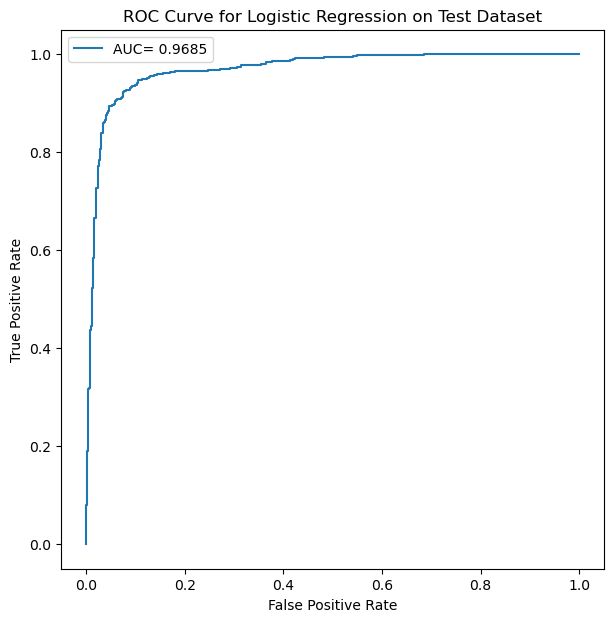

In [70]:
y_pred = lg.predict_proba(X_test)[:, 1] # get second column which is positive column

# ROC curve for linear regression classifer:
# gets false positive rate, true positive rate and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = auc(fpr, tpr) # get AUC metric for the curve

# plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label=f'AUC= {auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression on Test Dataset')
plt.legend()
plt.show()

4. Write code to plot a ROC curve without a package for logistic regression. Vary the prediction threshold $T \in \{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}$, and compute false positive and true positive rates for each threshold. Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3). What are the differences and what changes can you make to get the two ROC curves to become more similar?

In [72]:
lg.predict_proba(X_test)[:, 1]

array([2.16812276e-01, 2.55880025e-01, 1.47340431e-02, ...,
       8.66723445e-01, 1.86537959e-01, 2.20308706e-05])

In [78]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.8, 0.9, 1]

# FPR = FP/FP+TN | FP = actual class = 0 but score >= threshold
# compare model probabilities to threshold

probs = np.array(lg.predict_proba(X_test)[:, 1])
y_true = np.array(y_test)
fprs = []
for T in thresholds:
    
    for p in probs:
        if p >= T:
          y_pred = 1
        else: y_pred = 0
        
    TP = ((y_pred == 1) & (y_true == 1)).sum()
    FP = ((y_pred == 1) & (y_true == 0)).sum()
    TN = ((y_pred == 0) & (y_true == 0)).sum()
    FN = ((y_pred == 0) & (y_true == 1)).sum()

    fpr = FP/(FP+TN)
    fprs.append(fpr)
    
fpr

/var/folders/wy/r8w5zhp57c3ct782q7w9zw5h0000gn/T/ipykernel_1059/1845921562.py:20: RuntimeWarning: invalid value encountered in divide
  fpr = FP/(FP+TN)


array([[ 0.],
       [ 0.],
       [ 0.],
       ...,
       [nan],
       [ 0.],
       [ 0.]])